# Coastal tide predictions

NOAA's Center for Operational Oceanographic Products and Services (CO-OPS)
predicts the astronomical tide at its stations from each station's harmonic
constituents: the amplitudes and phases of the tidal periods fitted to years
of that station's observed water levels. The CO-OPS Data API computes the
predictions on request, for one station, one vertical datum, and up to a
year, on a six-minute or other fixed step or as the times and heights of
high and low water. One request returns one CSV.

This walkthrough pulls the predicted high and low waters at The Battery, New
York, for May 2024. It needs `usdata[pandas]` and matplotlib, and downloads
one 3 kB file in a second or two.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:03:43+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one station by its seven-digit ID (`8518750` is The
Battery), the vertical datum, the units, the interval, and a window. `MLLW`
is mean lower low water, so zero is an ordinary low tide; `units: metric`
asks for metres. `interval: hilo` returns only the predicted high and low
waters. The default, `6`, returns a height every six minutes, which lines up
row for row with the [observed water levels](https://usdata.dev/datasets/noaa/coops-water-levels/)
requested on the same station, datum, and window.

Both bounds are inclusive and in UTC, and a bare date as the end means 23:59
on that day, so these dates select all of May. One source covers at most 366
days.

In [2]:
print(manifest.read_text())

name: battery-tide-predictions
sources:
  - dataset: noaa:coops-tide-predictions
    start: 2024-05-01
    end: 2024-05-31
    params:
      station: "8518750"
      datum: MLLW
      units: metric
      interval: hilo



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. The source URL is the only place the
request's station, datum, units, interval, and time zone are recorded.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: predictions_8518750_fc146504aa50b033.csv
Bytes: 2996
Source: https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=8518750&product=predictions&begin_date=20240501+00%3A00&end_date=20240531+23%3A59&datum=MLLW&units=metric&interval=hilo&time_zone=gmt&format=csv&application=usdata
Retrieved (UTC): 2026-09-24T06:03:44+00:00
Checksum: sha256:d4be2e04d5b311113d5e6249b236b3c599a83f3c6019c384800fec7d57530402


## Open

The generic CSV reader returns NOAA's column names with their leading spaces;
strip them locally. `Date Time` is text in UTC with no offset, `Prediction`
is metres above MLLW, and `Type` is `H` or `L`, a column only the `hilo`
interval has. Predictions are computed, not measured, so there are no
quality flags and no gaps.

In [4]:
frame = item.open().rename(columns=str.strip)
frame["Date Time"] = pd.to_datetime(frame["Date Time"], utc=True)
print(f"{len(frame)} rows, {frame['Date Time'].min()} to {frame['Date Time'].max()}")
print("Type:", frame["Type"].value_counts().to_dict())
frame.head()

119 rows, 2024-05-01 06:07:00+00:00 to 2024-05-31 19:41:00+00:00
Type: {'H': 60, 'L': 59}


,Date Time,Prediction,Type
0,2024-05-01 06:07:00+00:00,1.455,H
1,2024-05-01 13:09:00+00:00,0.164,L
2,2024-05-01 18:57:00+00:00,1.256,H
3,2024-05-02 01:23:00+00:00,0.290,L
4,2024-05-02 07:12:00+00:00,1.450,H


## A first look

Every predicted high and low water of the month. The vertical lines mark the
new moon (8 May, 03:22 UTC) and the full moon (23 May, 13:53 UTC).

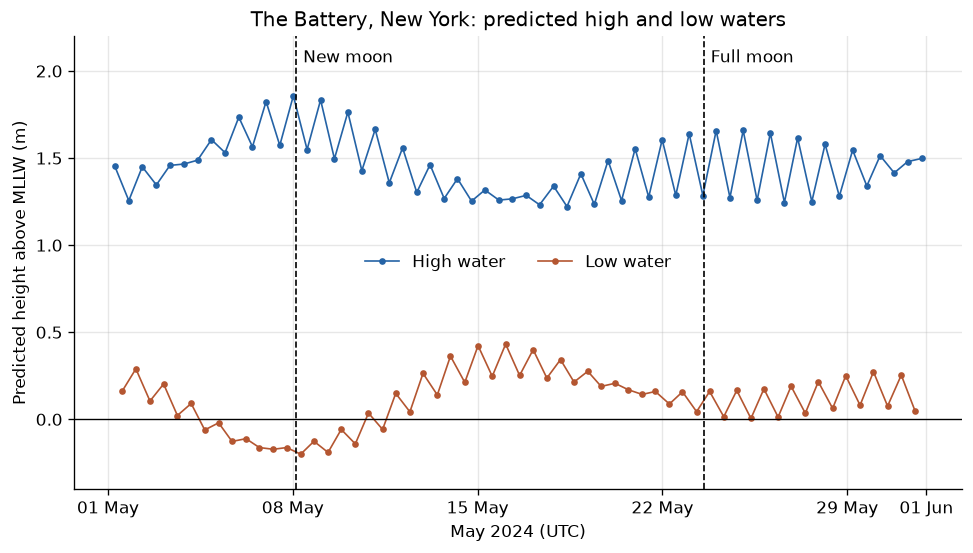

In [5]:
highs = frame[frame["Type"] == "H"]
lows = frame[frame["Type"] == "L"]
fig, ax = plt.subplots(layout="constrained")
for rows, color, label in [(highs, "#2563a6", "High water"), (lows, "#b45631", "Low water")]:
    ax.plot(rows["Date Time"], rows["Prediction"], "o-", ms=3, lw=1, color=color, label=label)
for moon, label in [("2024-05-08 03:22", "New moon"), ("2024-05-23 13:53", "Full moon")]:
    when = pd.Timestamp(moon, tz="UTC")
    ax.axvline(when, color="black", lw=1, ls="--")
    ax.annotate(label, (when, 2.05), xytext=(4, 0), textcoords="offset points")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(-0.4, 2.2)
ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 8, 15, 22, 29]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlabel("May 2024 (UTC)")
ax.set_ylabel("Predicted height above MLLW (m)")
ax.set_title("The Battery, New York: predicted high and low waters")
ax.legend(loc="center", frameon=False, ncols=2)
plt.show()

In [6]:
# The range of each tide: every change from one extreme to the next.
ranges = frame["Prediction"].diff().abs().set_axis(frame["Date Time"]).dropna()
top, bottom = frame.loc[highs["Prediction"].idxmax()], frame.loc[lows["Prediction"].idxmin()]
print(f"Highest high water: {top['Prediction']:.3f} m at {top['Date Time']:%d %b %H:%M} UTC")
print(f"Lowest low water: {bottom['Prediction']:.3f} m at {bottom['Date Time']:%d %b %H:%M} UTC")
print(f"Largest range: {ranges.max():.2f} m, ending {ranges.idxmax():%d %b %H:%M} UTC")
print(f"Smallest range: {ranges.min():.2f} m, ending {ranges.idxmin():%d %b %H:%M} UTC")

Highest high water: 1.858 m at 08 May 00:31 UTC
Lowest low water: -0.200 m at 08 May 07:14 UTC
Largest range: 2.06 m, ending 08 May 07:14 UTC
Smallest range: 0.83 m, ending 16 May 01:32 UTC


The range swells and shrinks twice in the month: largest near the new and
full moons (spring tides), smallest between them (neap tides), from 2.06 m
between the high and low water of 8 May down to 0.83 m on 16 May. The two
springs are not equal. The 8 May new moon came within days of the Moon's
closest approach of the month, and both the highest high and the lowest low
water fell that day. The zigzag in each line is the daily inequality: one of
the day's two high waters stands above the other, by as much as 0.4 m in late
May.

The prediction for 00:31 UTC on 8 May was 1.858 m; the
[observed water level](https://usdata.dev/datasets/noaa/coops-water-levels/)
that night peaked at 2.06 m. Observation minus prediction is the non-tidal
residual, which the [storm surge study](https://usdata.dev/studies/storm-surge/)
measures during Hurricane Helene.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:coops-tide-predictions
  NOAA National Ocean Service, Center for Operational Oceanographic Products and Services, tide predictions, accessed via usdata
  homepage: https://api.tidesandcurrents.noaa.gov/api/prod/
  license: US Government Work (public domain)
  terms: https://tidesandcurrents.noaa.gov/disclaimers.html
  retrieved: 2026-09-24; 1 checksummed asset (2,996 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- NOAA's column names keep their leading spaces (`" Prediction"`), so the
  columns have to be stripped before use.
- The CSV carries no station, datum, units, or interval. They are recorded
  only in the source URL, so the manifest has to travel with the data.
- The columns depend on the interval: `Type` exists only with `hilo`, so code
  written for six-minute predictions breaks on high/low ones and the reverse.
- Predictions are computed on request from constituents NOAA revises now and
  then, so the same request can later return different bytes. The lockfile
  records what this run received.
- Subordinate stations serve only `hilo`; other intervals fail at fetch time
  rather than when the manifest is checked.